In [3]:
import cv2
import matplotlib.pyplot as plt

In [4]:
#Reading the image
img = cv2.imread('happy face.jpg')

In [5]:
print(type(img))

<class 'numpy.ndarray'>


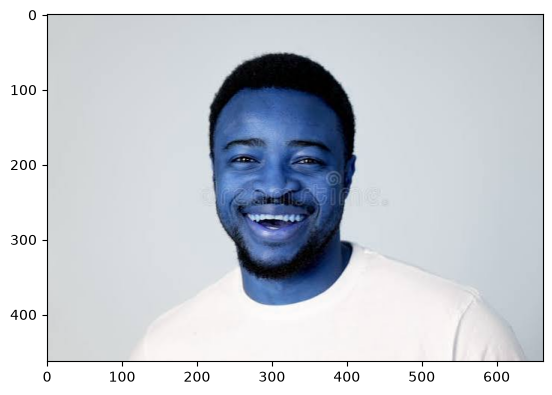

In [6]:
plt.imshow(img)

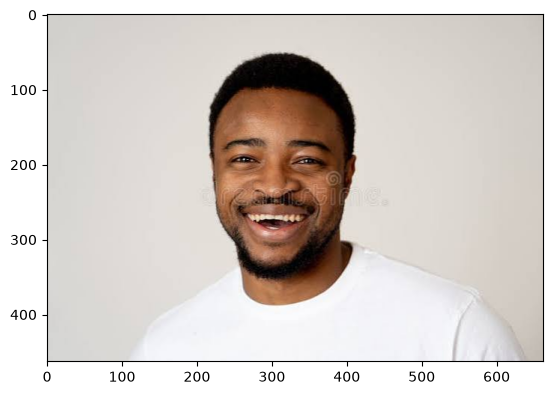

In [7]:
#Image in BGR format
#Converting it to RGB
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [8]:
from deepface import DeepFace

pred = DeepFace.analyze(img)


Action: race: 100%|██████████████████████████████████████████████████████████████████████| 4/4 [00:17<00:00,  4.42s/it]


In [9]:
#Predicting 'emotion' category
pred1 = DeepFace.analyze(
    img,
    actions=["emotion"]
)

print(pred1)

[{'emotion': {'angry': np.float32(1.0841962e-09), 'disgust': np.float32(8.1510155e-16), 'fear': np.float32(1.1971168e-13), 'happy': np.float32(97.852776), 'sad': np.float32(1.0017583e-08), 'surprise': np.float32(4.523257e-05), 'neutral': np.float32(2.147183)}, 'dominant_emotion': 'happy', 'region': {'x': 205, 'y': 113, 'w': 201, 'h': 201, 'left_eye': None, 'right_eye': None}, 'face_confidence': 0.91}]


In [10]:
type(pred1)

list

In [11]:
type(pred)

list

In [12]:
import cv2

faceCascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Classifier empty:", faceCascade.empty())

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Gray shape:", gray.shape)

print("Cascade path:")
print(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

faces = faceCascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4
)

print(faces)

Classifier empty: False
Gray shape: (463, 662)
Cascade path:
D:\anaconda__\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
[[203 111 207 207]]


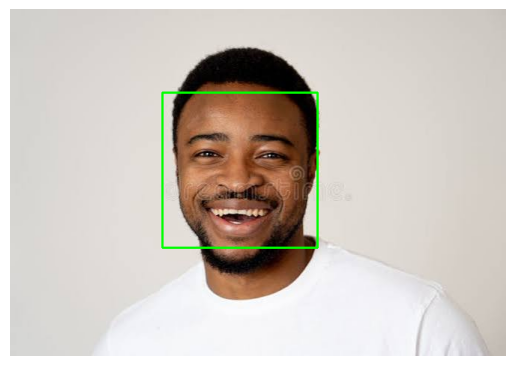

In [13]:
img = cv2.imread("happy face.jpg")

#Plotting a rectangle around face
for (x, y, w, h) in faces:
    cv2.rectangle(
        img,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

<font size="5">Adding text on Image</font>

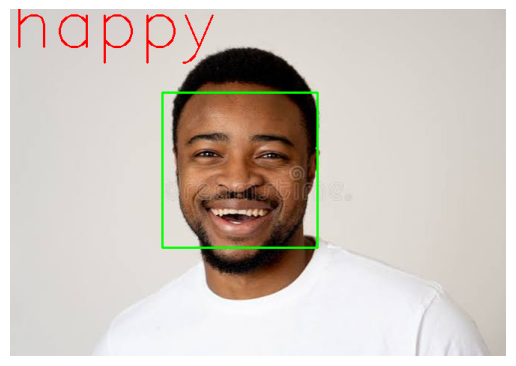

In [14]:
#Adding font style
font = cv2.FONT_HERSHEY_SIMPLEX

#Adding the font i.e, 'dominant_emotion'
cv2.putText(
    img,
    pred[0]['dominant_emotion'],
    (0, 50),
    font,
    3,
    (0, 0, 255),
    2
)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

<font size=5>**Real Time Demo**</font>

In [ ]:
import cv2
from deepface import DeepFace

cap = cv2.VideoCapture(0)

faceCascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    result = DeepFace.analyze(
        frame,
        actions=["emotion"],
        enforce_detection=False
    )

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    cv2.putText(
        frame,
        result[0]["dominant_emotion"],
        (20, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    cv2.imshow("Demo Video", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()